# Stage 1: PubMedQA Data Exploration

This notebook implements Stage 1 for the biomedical tokenization case study.

In [4]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
def get_context_text(context_field):
    if isinstance(context_field, dict):
        contexts = context_field.get("contexts", [])
        if isinstance(contexts, list):
            return " ".join(str(part) for part in contexts)
    if isinstance(context_field, list):
        return " ".join(str(part) for part in context_field)
    return str(context_field)


def count_words(text):
    return len(text.split())


def plot_length_distribution(lengths, title):
    data = list(lengths)
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=30)
    plt.title(title)
    plt.xlabel("Number of words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


def extract_complex_terms(texts, min_length=12, top_k=100):
    counter = {}
    pattern = re.compile(r"\b[A-Za-z][A-Za-z\-]{%d,}\b" % (min_length - 1))
    for text in texts:
        for match in pattern.findall(text):
            term = match.lower()
            counter[term] = counter.get(term, 0) + 1
    top = sorted(counter.items(), key=lambda item: item[1], reverse=True)[:top_k]
    return pd.DataFrame(top, columns=["term", "count"])

Stage 1 summary metrics:
- labeled_samples: 1000
- unlabeled_samples: 61249
- avg_question_words: 12.913
- avg_context_words: 200.207
- label_distribution: {'yes': 552, 'no': 338, 'maybe': 110}

Top 20 TF-IDF terms:


,term,score
200,patients,0.113092
129,group,0.053672
267,study,0.042124
299,years,0.032859
239,risk,0.032406
281,treatment,0.031605
43,age,0.030982
297,women,0.030444
130,groups,0.029143
288,using,0.028507


Top 20 complex terms:


,term,count
0,significantly,399
1,respectively,224
2,postoperative,143
3,statistically,134
4,retrospective,127
5,participants,126
6,complications,120
7,relationship,107
8,questionnaire,90
9,multivariate,84


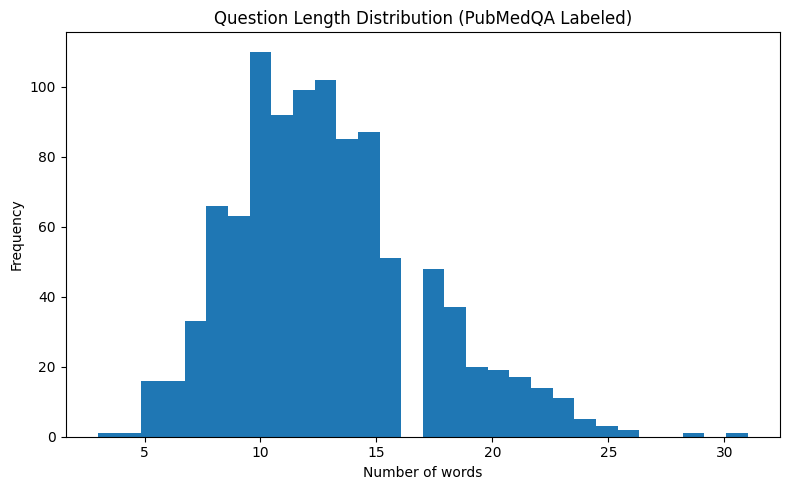

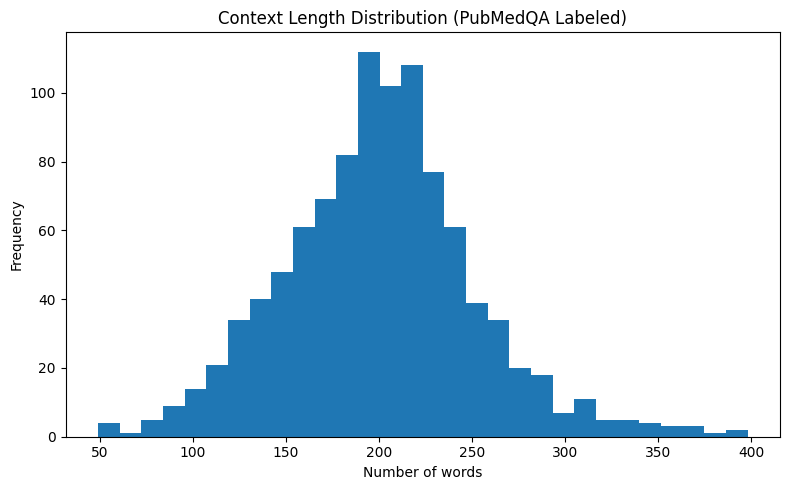

{'labeled_samples': 1000,
 'unlabeled_samples': 61249,
 'avg_question_words': 12.913,
 'avg_context_words': 200.207,
 'label_distribution': {'yes': 552, 'no': 338, 'maybe': 110}}

In [6]:
labeled = load_dataset("qiaojin/PubMedQA", "pqa_labeled")["train"]
unlabeled = load_dataset("qiaojin/PubMedQA", "pqa_unlabeled")["train"]

df_labeled = pd.DataFrame({
    "question": labeled["question"],
    "context_text": [get_context_text(ctx) for ctx in labeled["context"]],
    "label": labeled["final_decision"],
})

df_unlabeled = pd.DataFrame({
    "question": unlabeled["question"],
    "context_text": [get_context_text(ctx) for ctx in unlabeled["context"]],
})

df_labeled["question_word_count"] = df_labeled["question"].map(count_words)
df_labeled["context_word_count"] = df_labeled["context_text"].map(count_words)

summary = {
    "labeled_samples": int(len(df_labeled)),
    "unlabeled_samples": int(len(df_unlabeled)),
    "avg_question_words": float(np.mean(df_labeled["question_word_count"])),
    "avg_context_words": float(np.mean(df_labeled["context_word_count"])),
    "label_distribution": df_labeled["label"].value_counts().to_dict(),
}

combined_text = (df_unlabeled["question"].fillna("") + " " + df_unlabeled["context_text"].fillna("")).tolist()
vectorizer = TfidfVectorizer(max_features=300, ngram_range=(1, 1), stop_words="english")
matrix = vectorizer.fit_transform(combined_text)
scores = np.asarray(matrix.mean(axis=0)).ravel()
terms = np.array(vectorizer.get_feature_names_out())
tfidf_df = pd.DataFrame({"term": terms, "score": scores}).sort_values(by="score", ascending=False)

complex_terms_df = extract_complex_terms(df_labeled["context_text"].tolist(), min_length=12, top_k=100)

print("Stage 1 summary metrics:")
for key, value in summary.items():
    print(f"- {key}: {value}")

print("\nTop 20 TF-IDF terms:")
display(tfidf_df.head(20))

print("Top 20 complex terms:")
display(complex_terms_df.head(20))

plot_length_distribution(
    df_labeled["question_word_count"],
    "Question Length Distribution (PubMedQA Labeled)",
)
plot_length_distribution(
    df_labeled["context_word_count"],
    "Context Length Distribution (PubMedQA Labeled)",
)

summary